<a href="https://colab.research.google.com/github/MarlzRana/machine-learning/blob/main/temp_model_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import math

In [ ]:
def truncate_to_three_decimal_places(num):
    # Convert the number to a string
    num_str = str(num)
    # Split the string on the decimal point
    parts = num_str.split('.')
    # If the number is a float and has a decimal part
    if len(parts) > 1:
        decimal_part = parts[1]
        # Truncate the decimal part to three characters if longer, or pad if shorter
        truncated_decimal = (decimal_part + "000")[:3]  # Add zeros and then truncate to ensure length
        # Reassemble the number with the truncated decimal part
        truncated_num_str = parts[0] + '.' + truncated_decimal
    else:
        # If there is no decimal part, add '.000'
        truncated_num_str = parts[0] + '.000'

    return truncated_num_str


def round_up_third_decimal(num):
    # Scale the number to keep three decimal places as a whole number
    scaled_num = num * 1000
    # Apply math.ceil to round up the number
    rounded_num = math.ceil(scaled_num)
    # Scale back to the original number of decimal places
    final_num = rounded_num / 1000
    # Convert the number to a string
    final_num_str = f"{final_num:.3f}"  # Ensures at least three decimal places
    return final_num_str

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_res = pd.read_csv("/content/drive/My Drive/3yp/results/temporal_results_cleaned.csv")

In [ ]:
df_res.iloc[3]["model_name"]

'exp_recurrent_sru_unet_resnet18b_non_trainable_teacher_forcing_adjusted_weighted_dice_loss'

In [ ]:
df_res.loc[df_res['model_name'] == 'mod_unet_resnet_18_a', 'model_name'] = 'ResNet18-U-Net-A'
df_res.loc[df_res['model_name'] == 'mod_unet_resnet_18_b', 'model_name'] = 'ResNet18-U-Net-B'

df_res.loc[df_res['model_name'] == 'mod_unet_resnet_34_b', 'model_name'] = 'ResNet34-U-Net-B'
df_res.loc[df_res['model_name'] == 'mod_unet_resnet_34_b', 'model_name'] = 'ResNet34-U-Net-B'


df_res.loc[df_res['model_name'] == 'exp_recurrent_sru_unet_resnet18b_non_trainable_teacher_forcing_adjusted_weighted_dice_loss', 'model_name'] = 'Temporal Model'

df_res["first_frame_runtime"] = [41.227, 91.739, 127.540, 91.739]

df_res["subsequent_frame_runtime"] = [41.227, 91.739, 127.540, 20.121]


In [ ]:
df_res

,model_name,overall_iou,overall_dice_coefficient,mean_iou,mean_dice_coefficient,0_iou_road,0_dice_coefficient_road,1_iou_sidewalk,1_dice_coefficient_sidewalk,2_iou_human,...,4_iou_object,4_dice_coefficient_object,5_iou_construction,5_dice_coefficient_construction,6_iou_nature,6_dice_coefficient_nature,7_iou_sky,7_dice_coefficient_sky,first_frame_runtime,subsequent_frame_runtime
0,ResNet18-U-Net-A,0.748916,0.852392,0.503519,0.596622,0.665741,0.733854,0.397144,0.539562,0.184923,...,0.263963,0.399065,0.392641,0.479226,0.818064,0.893008,0.733241,0.812829,41.227,41.227
1,ResNet18-U-Net-B,0.787433,0.877234,0.568562,0.658726,0.685676,0.749633,0.495733,0.631554,0.290279,...,0.375964,0.527327,0.416013,0.500347,0.855652,0.917741,0.773956,0.841971,91.739,91.739
2,ResNet34-U-Net-B,0.788843,0.878385,0.562731,0.653877,0.683343,0.745771,0.502817,0.636485,0.240932,...,0.387607,0.541788,0.428524,0.516736,0.849775,0.913557,0.771033,0.838897,127.540,127.540
3,Temporal Model,0.640477,0.776415,0.425011,0.519545,0.624252,0.707775,0.341879,0.464223,0.077401,...,0.210311,0.321980,0.323497,0.424398,0.724032,0.831194,0.708023,0.797657,91.739,20.121


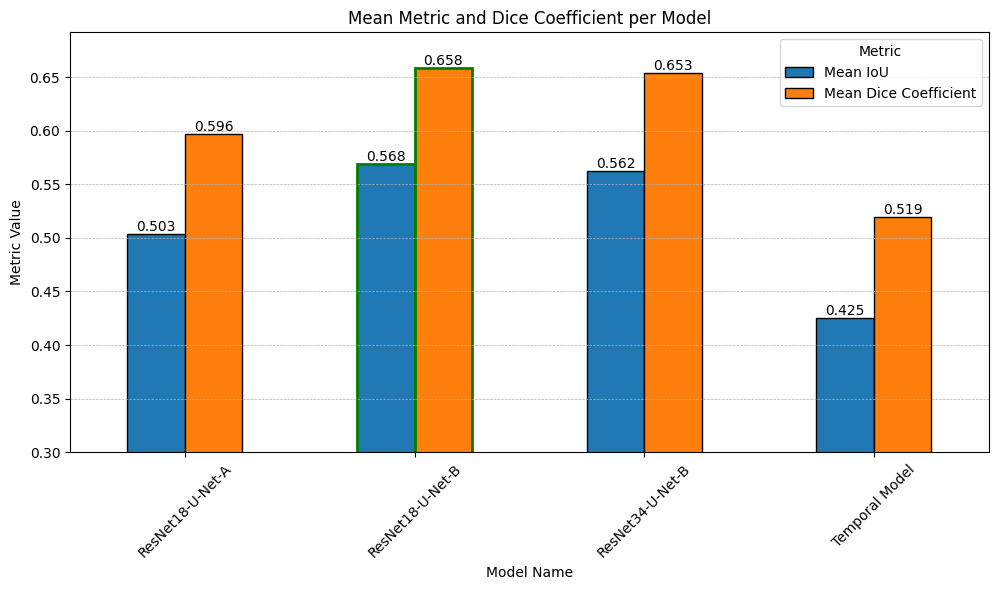

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_res contains your data
# Find the row with the maximum IoU and Dice coefficient
best_iou_index = df_res['mean_iou'].idxmax()
best_dice_index = df_res['mean_dice_coefficient'].idxmax()

# Plot the bar chart
ax = df_res.plot(x="model_name", y=["mean_iou", "mean_dice_coefficient"], kind="bar", figsize=(10, 6))

# Highlight the bars with the best IoU and Dice coefficient by setting the edge color
for i, bar in enumerate(ax.patches):
    if i == best_iou_index or i == best_dice_index + len(df_res):
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bars

# Add title, labels, grid, and legend
plt.title("Mean Metric and Dice Coefficient per Model")
plt.xlabel("Model Name")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)  # Only horizontal grid lines
plt.tight_layout()
plt.legend(["Mean IoU", "Mean Dice Coefficient"], title='Metric')

ax.set_ylim(bottom=0.3)

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{truncate_to_three_decimal_places(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

plt.show()


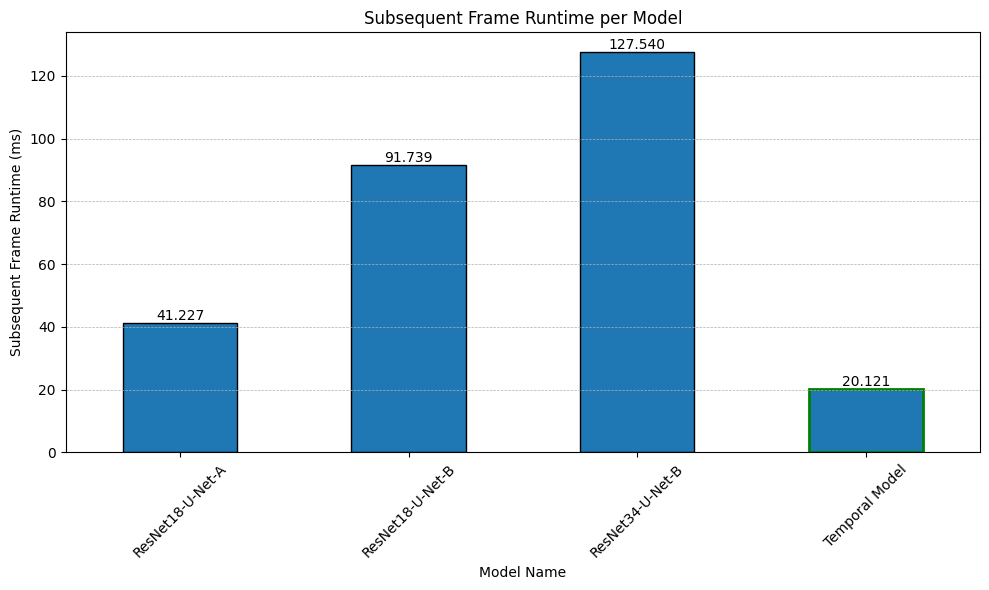

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_res contains your data
# Find the row with the minimum runtime
best_index = df_res['subsequent_frame_runtime'].idxmin()

# Plot the bar chart
ax = df_res.plot(x="model_name", y=["subsequent_frame_runtime"], kind="bar", figsize=(10, 6), legend=None)

# Highlight the bar with the best runtime by setting the edge color
for i, bar in enumerate(ax.patches):
    if i == best_index:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)  # Adjust border width as needed
    else:
        bar.set_edgecolor('black')  # Set edge color for other bars

# Add title, labels, grid, and legend
plt.title("Subsequent Frame Runtime per Model")
plt.xlabel("Model Name")
plt.ylabel("Subsequent Frame Runtime (ms)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)  # Only horizontal grid lines
plt.tight_layout()

# Annotate the bars with their values
for p in ax.patches:
    ax.annotate(f"{round_up_third_decimal(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', rotation=0, xytext=(0, 5),
                textcoords='offset points')

plt.show()


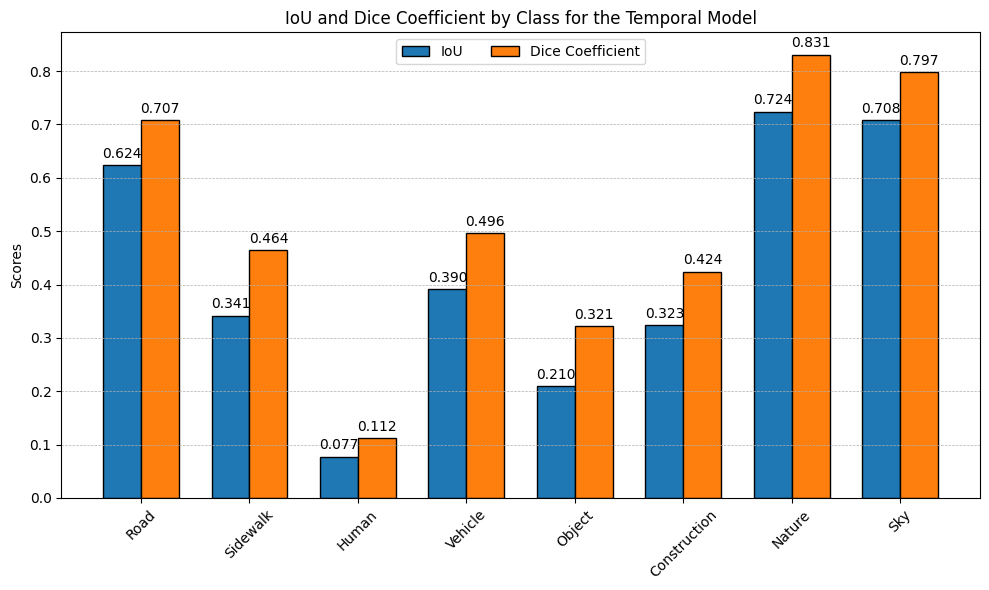

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Assume df_res is your DataFrame already loaded with data
# Filtering the data for the model 'ResNet34-U-Net-B'
data = df_res.loc[df_res["model_name"] == "Temporal Model"]

# Extracting IoU and Dice Coefficients for each class
classes = ['Road', 'Sidewalk', 'Human', 'Vehicle', 'Object', 'Construction', 'Nature', 'Sky']
iou_values = [data[f'{i}_iou_{cls.lower()}'].values[0] for i, cls in enumerate(classes)]
dice_values = [data[f'{i}_dice_coefficient_{cls.lower()}'].values[0] for i, cls in enumerate(classes)]

x = np.arange(len(classes))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, iou_values, width, label='IoU', edgecolor='black')
rects2 = ax.bar(x + width/2, dice_values, width, label='Dice Coefficient', edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('IoU and Dice Coefficient by Class for the Temporal Model')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Function to add labels on the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{truncate_to_three_decimal_places(height)}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

ax.set_ylim(bottom=0.0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), fancybox=True, ncol=2)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
